# EDA (Exploratory Data Analysis, 탐색적 데이터 분석)¶

## 1. 데이터 준비

In [6]:
# ---------------------------------------------------------------
# 시각화 한글 폰트 및 핵심 라이브러리 로드
# ---------------------------------------------------------------
import os
import glob
import warnings
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

# 1. 시각화 한글 폰트 설정 (OS 자동 감지)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

system_name = platform.system()
if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux, Colab, Ubuntu
    plt.rcParams["font.family"] = "NanumGothic"

pd.set_option("display.max_columns", 100)

In [7]:
file_path = 'data/한국어_연속적_대화_데이터셋.xlsx'

# header=1로 첫 행('발화', '감정')을 제외하고 불러옵니다.
# openpyxl 엔진을 명시적으로 지정하여 안전하게 읽어옵니다.
df = pd.read_excel(file_path, usecols=[1, 2], header=1, engine='openpyxl')
df.columns = ['text', 'label']

# 결측치 제거
df = df.dropna().reset_index(drop=True)

print("✅ 데이터 로드 성공! 총 개수:", len(df))
print(df.head())

✅ 데이터 로드 성공! 총 개수: 55621
                                           text label
0          아 진짜! 사무실에서 피지 말라니깐! 간접흡연이 얼마나 안좋은데!    분노
1  그럼 직접흡연하는 난 얼마나 안좋겠니? 안그래? 보면 꼭... 지 생각만 하고.    혐오
2                                       손님 왔어요.    중립
3                                       손님? 누구?    중립
4                                몰라요. 팀장님 친구래요.    중립


In [8]:
# 1. 우리가 사용할 7가지 감정 리스트 정의
target_emotions = ['행복', '중립', '슬픔', '공포', '혐오', '분노', '놀람']

# 2. 7가지 감정에 포함되는 데이터만 필터링 (나머지는 자동 삭제)
df = df[df['label'].isin(target_emotions)].reset_index(drop=True)

# 3. 필터링된 감정 글자를 숫자로 변환 (라벨 인코딩)
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# 총 감정의 종류 개수 (7개가 나와야 합니다)
num_classes = len(label_encoder.classes_)

print("--- 데이터 필터링 및 인코딩 완료 ---")
print(f"7가지 감정만 남긴 후 전체 데이터 개수: {len(df)}개")
print(f"분류할 감정의 총 개수: {num_classes}개")
print("\n최종 감정 태그 매핑 결과:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

--- 데이터 필터링 및 인코딩 완료 ---
7가지 감정만 남긴 후 전체 데이터 개수: 55600개
분류할 감정의 총 개수: 7개

최종 감정 태그 매핑 결과:
{'공포': np.int64(0), '놀람': np.int64(1), '분노': np.int64(2), '슬픔': np.int64(3), '중립': np.int64(4), '행복': np.int64(5), '혐오': np.int64(6)}


In [13]:
# ==========================================
# 1. 자바(JVM) 경로 설정 및 Okt 분석기 연결
# ==========================================
java_home_str = str(jdk4py.JAVA_HOME)
os.environ["JAVA_HOME"] = java_home_str

jvm_path_list = glob.glob(os.path.join(java_home_str, "**", "libjvm.dylib"), recursive=True)

if jvm_path_list:
    jvm_path = jvm_path_list[0]
    okt = Okt(jvmpath=jvm_path)
    print("✅ 자바 엔진 연결 성공!")
else:
    okt = Okt()
    print("⚠️ jvm_path를 찾지 못해 기본 경로로 초기화합니다.")

# ==========================================
# 2. 형태소 분석 기반 한국어 토큰화 (어간 추출 & 핵심 품사 추출)
# ==========================================
def tokenize_korean(text):
    clean_words = []
    # 명사, 동사, 형용사, 부사, 감탄사만 추출하고 원형(stem=True)으로 정규화
    for word, pos in okt.pos(str(text), stem=True):
        if pos in ['Noun', 'Verb', 'Adjective', 'Adverb', 'Exclamation']:
            clean_words.append(word)
    return clean_words

print("\n⏳ 텍스트 토큰화를 진행 중입니다...")
df['tokenized'] = df['text'].apply(tokenize_korean)

print("--- 텍스트 전처리 및 토큰화 완료 ---")
# print(f"전체 정제 데이터 개수: {len(df)}개")
# print("감정 태그 매핑 결과:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
print("\n[전처리 완료 데이터 미리보기]")
print(df[['text', 'label', 'tokenized']].head())

✅ 자바 엔진 연결 성공!

⏳ 텍스트 토큰화를 진행 중입니다...
--- 텍스트 전처리 및 토큰화 완료 ---

[전처리 완료 데이터 미리보기]
                                           text label  \
0          아 진짜! 사무실에서 피지 말라니깐! 간접흡연이 얼마나 안좋은데!    분노   
1  그럼 직접흡연하는 난 얼마나 안좋겠니? 안그래? 보면 꼭... 지 생각만 하고.    혐오   
2                                       손님 왔어요.    중립   
3                                       손님? 누구?    중립   
4                                몰라요. 팀장님 친구래요.    중립   

                                           tokenized  
0                [아, 진짜, 사무실, 피지, 말, 간접흡연, 얼마나, 안좋다]  
1  [그렇다, 직접, 흡연, 난, 얼마나, 안좋다, 그렇다, 보다, 꼭, 지다, 생각,...  
2                                           [손님, 오다]  
3                                           [손님, 누구]  
4                                [모르다, 팀, 장님, 친구, 요]  


[분석]
- 핵심 품사를 필터링하여 선별 추출해 조사 기호 등의 노이즈 제거
- 다양한 용언을 원형이 되는 언어인 슬프다로 통일하여 단어 사전을 압축

## 2. 데이터 정보 확인

In [14]:
# 2-1. Shape 확인
df.shape

(55600, 4)

In [15]:
# 2-2. info() 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55600 entries, 0 to 55599
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           55600 non-null  str   
 1   label          55600 non-null  str   
 2   label_encoded  55600 non-null  int64 
 3   tokenized      55600 non-null  object
dtypes: int64(1), object(1), str(2)
memory usage: 1.7+ MB


In [16]:
# 2-3. describe() - 5수 요약(Five-Number Summary)
# 유일한 수치형인 label_encoded는 중요도가 낮기 때문에 생략

# 문자형 컬럼 요약 통계만 진행
df.describe(include=["str", "object"])

,text,label,tokenized
count,55600,55600,55600
unique,51211,7,47645
top,네?,중립,[네]
freq,298,43786,737


In [17]:
# 2-4 결측치
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("결측치가 있는 컬럼:")
print(missing if len(missing) else "없음")
print("\n결측치가 있는 컬럼 개수:", len(missing))


결측치가 있는 컬럼:
없음

결측치가 있는 컬럼 개수: 0


In [18]:
# 2-5. 데이터 타입¶
print("\n컬럼별 데이터 타입:")
print(df.dtypes)


컬럼별 데이터 타입:
text                str
label               str
label_encoded     int64
tokenized        object
dtype: object


In [19]:
# 각 문장별 단어 수 계산
token_lengths = df['tokenized'].apply(len)

print("=== 📏 문장 길이(단어 수) 통계 ===")
print(f" - 평균 단어 수              : {token_lengths.mean():.2f}개")
print(f" - 중간값 단어 수            : {token_lengths.median():.0f}개")
print(f" - 최대 단어 수              : {token_lengths.max()}개")
print(f" - 전체의 95%를 커버하는 길이: {np.percentile(token_lengths, 95):.0f}개")
print(f" - 전체의 99%를 커버하는 길이: {np.percentile(token_lengths, 99):.0f}개")

=== 📏 문장 길이(단어 수) 통계 ===
 - 평균 단어 수              : 6.81개
 - 중간값 단어 수            : 5개
 - 최대 단어 수              : 71개
 - 전체의 95%를 커버하는 길이: 18개
 - 전체의 99%를 커버하는 길이: 26개


In [20]:
print("=== 📊 타겟 라벨(감정) 분포 ===")
label_counts = df['label'].value_counts()
for label, count in label_counts.items():
    ratio = (count / len(df)) * 100
    print(f" - {label:5s}: {count:6d}개 ({ratio:.2f}%)")

=== 📊 타겟 라벨(감정) 분포 ===
 - 중립   :  43786개 (78.75%)
 - 놀람   :   4866개 (8.75%)
 - 분노   :   3628개 (6.53%)
 - 슬픔   :   1972개 (3.55%)
 - 행복   :   1030개 (1.85%)
 - 혐오   :    220개 (0.40%)
 - 공포   :     98개 (0.18%)


findfont: Failed to find font weight bold, now using 400.


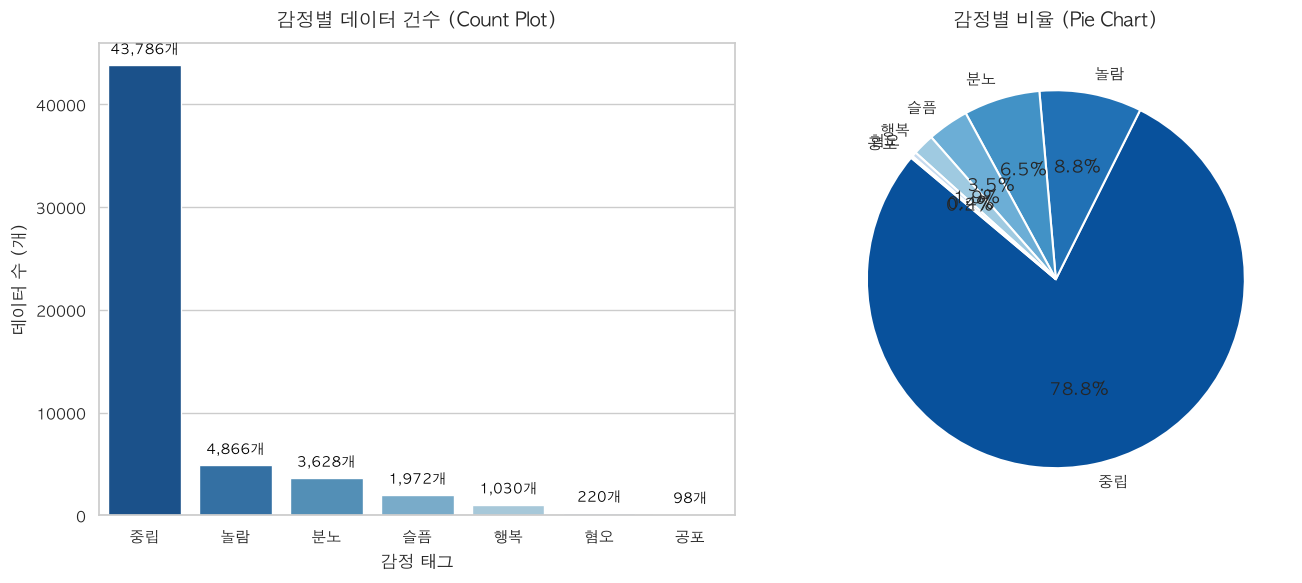

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# ==========================================
# 0. 한글 폰트 및 그래프 스타일 세팅 (Mac/Win 지원)
# ==========================================
if platform.system() == 'Darwin':  # Mac OS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':  # Windows OS
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지 및 스타일 설정
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", palette="pastel")
plt.rc('font', family='AppleGothic' if platform.system() == 'Darwin' else 'Malgun Gothic')

# ==========================================
# 1. 감정 분포 시각화 (막대 그래프 + 파이 차트)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (1) 막대 그래프 (Count Plot)
label_counts = df['label'].value_counts()
sns.barplot(
    x=label_counts.index, 
    y=label_counts.values, 
    ax=axes[0], 
    palette='Blues_r'
)
axes[0].set_title('감정별 데이터 건수 (Count Plot)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('감정 태그', fontsize=12)
axes[0].set_ylabel('데이터 수 (개)', fontsize=12)

# 막대 상단에 숫자 표기
for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height()):,}개',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10, color='black',
        xytext=(0, 5), textcoords='offset points'
    )

# (2) 파이 차트 (Ratio Plot)
axes[1].pie(
    label_counts.values, 
    labels=label_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('Blues_r', len(label_counts)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('감정별 비율 (Pie Chart)', fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

## 3. 데이터 전처리

In [22]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# ==========================================
# 1. 학습/테스트 데이터셋 분할 (8:2)
# ==========================================
# stratify 옵션을 사용하여 7가지 감정 비율이 균등하게 섞이도록 나눕니다.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['tokenized'].values, 
    df['label_encoded'].values, 
    test_size=0.2, 
    random_state=42,
    stratify=df['label_encoded'].values
)

print(f"학습 데이터 개수  : {len(X_train_raw)}개")
print(f"테스트 데이터 개수: {len(X_test_raw)}개")

# ==========================================
# 2. 단어 사전(Tokenizer) 구축
# ==========================================
max_words = 10000  # 가장 자주 등장하는 상위 10,000개 단어 사용
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

# 단어 사전 크기 확인
vocab_size = min(len(tokenizer.word_index) + 1, max_words)
print(f"구축된 단어 사전 크기: {vocab_size}개 단어")

# ==========================================
# 3. 텍스트 단어를 정수 시퀀스로 변환
# ==========================================
X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

# ==========================================
# 4. 시퀀스 패딩 (길이를 20으로 통일)
# ==========================================
max_len = 20  # 95% 커버 범위(18개) 기준 약간의 여유를 둔 20으로 설정

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print("\n--- 시퀀스 변환 및 패딩 완료 ---")
print(f"변환된 학습 데이터 형태(Shape): {X_train_pad.shape}")
print(f"변환된 테스트 데이터 형태(Shape): {X_test_pad.shape}")

# 첫 번째 샘플 확인
print("\n[변환 샘플 예시 (첫 번째 문장)]")
print(" - 원본 토큰:", X_train_raw[0])
print(" - 패딩 후 정수 배열:", X_train_pad[0])

학습 데이터 개수  : 44480개
테스트 데이터 개수: 11120개
구축된 단어 사전 크기: 10000개 단어

--- 시퀀스 변환 및 패딩 완료 ---
변환된 학습 데이터 형태(Shape): (44480, 20)
변환된 테스트 데이터 형태(Shape): (11120, 20)

[변환 샘플 예시 (첫 번째 문장)]
 - 원본 토큰: ['자네', '부친', '범죄', '말리다', '들다', '모르다', '아니다', '말로', '치장', '하다', '그만두다', '자네', '부친', '회사', '돈', '착취', '하다', '그것', '드러나다', '도망치다', '가능성', '있다']
 - 패딩 후 정수 배열: [ 277 3842 2371 1037   39   40    6 1170 8260    2  704  277 3842  141
   82 4356    2  302 4357 1358]


# 4. 모델 생성 및 평가

## 4-1. 베이스라인 딥러닝 모델 설계 및 학습 - model 1

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ==========================================
# 1. Bi-LSTM 모델 구조 설계
# ==========================================
base_model = Sequential([
    Input(shape=(max_len,)),
    # (1) 임베딩 층: 정수로 변환된 단어들을 128차원의 밀집 베터로 변환
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    
    # (2) 양방향 LSTM 층: 문장을 정방향/역방향 양쪽으로 읽어 문맥 파악 (출력 차원 64 x 2 = 128)
    Bidirectional(LSTM(64, return_sequences=False)),
    
    # (3) 드롭아웃: 과대적합(Overfitting) 방지를 위해 30% 노드 차단
    Dropout(0.3),
    
    # (4) 은닉층: 64개 노드의 Fully Connected Layer
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    # (5) 출력층: 7가지 감정 클래스 분류 (Softmax)
    Dense(7, activation='softmax')
])

# ==========================================
# 2. 모델 컴파일 (손실함수, 옵티마이저, 평가지표 설정)
# ==========================================
base_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

base_model.summary()

# ==========================================
# 3. 조기 종료 
# ==========================================
# 검증 손실(val_loss)이 3회 연속 개선되지 않으면 학습을 자동 종료합니다.
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

# ==========================================
# 4. 모델 학습 실행 (Fit)
# ==========================================
print("\n🚀 Bi-LSTM 모델 학습을 시작합니다...")
history = base_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.15,  # 학습 데이터 중 15%를 검증용으로 활용
    callbacks=early_stopping,
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 20, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,527 (5.29 MB)

 Trainable params: 1,387,527 (5.29 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Bi-LSTM 모델 학습을 시작합니다...
Epoch 1/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.7871 - loss: 0.8028 - val_accuracy: 0.7846 - val_loss: 0.7404
Epoch 2/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7923 - loss: 0.6926 - val_accuracy: 0.7872 - val_loss: 0.7243
Epoch 3/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.8028 - loss: 0.6086 - val_accuracy: 0.7809 - val_loss: 0.7518
Epoch 4/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.8179 - loss: 0.5422 - val_accuracy: 0.7785 - val_loss: 0.8133
Epoch 5/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.8336 - loss: 0.4886 - val_accuracy: 0.7735 - val_loss: 0.8821
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


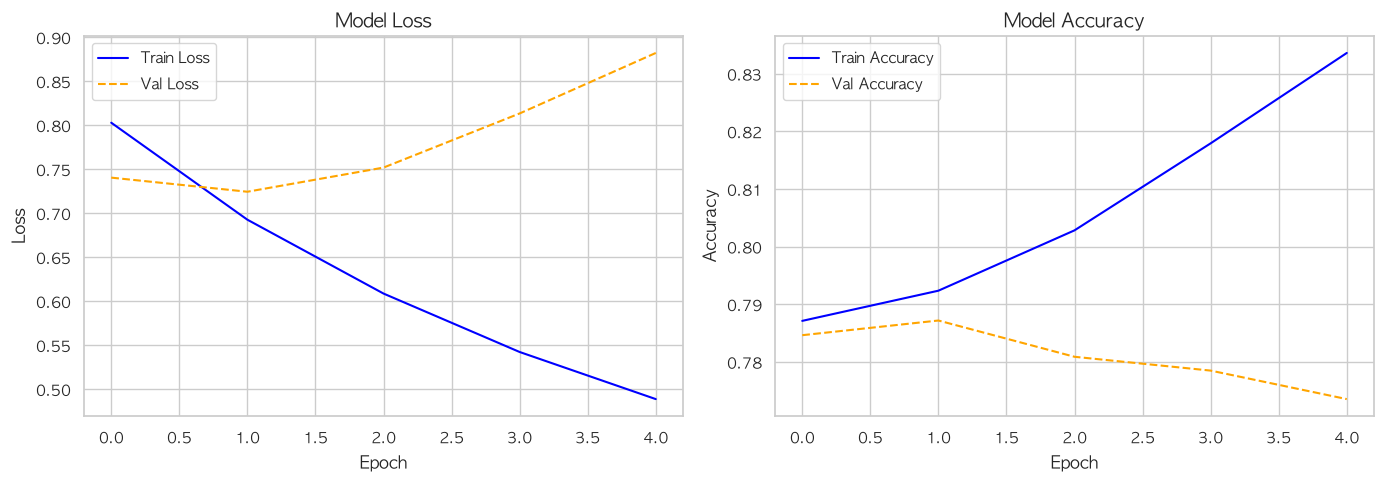


--- 🧪 테스트 데이터셋 최종 평가 ---
테스트 손실 (Test Loss)    : 0.7158
테스트 정확도 (Test Accuracy): 78.50%

=== 📋 상세 분류 리포트 (Classification Report) ===
              precision    recall  f1-score   support

          공포       0.00      0.00      0.00        20
          놀람       0.42      0.10      0.16       973
          분노       0.44      0.17      0.25       726
          슬픔       0.30      0.01      0.01       394
          중립       0.80      0.97      0.88      8757
          행복       0.50      0.02      0.04       206
          혐오       0.00      0.00      0.00        44

    accuracy                           0.78     11120
   macro avg       0.35      0.18      0.19     11120
weighted avg       0.72      0.78      0.72     11120



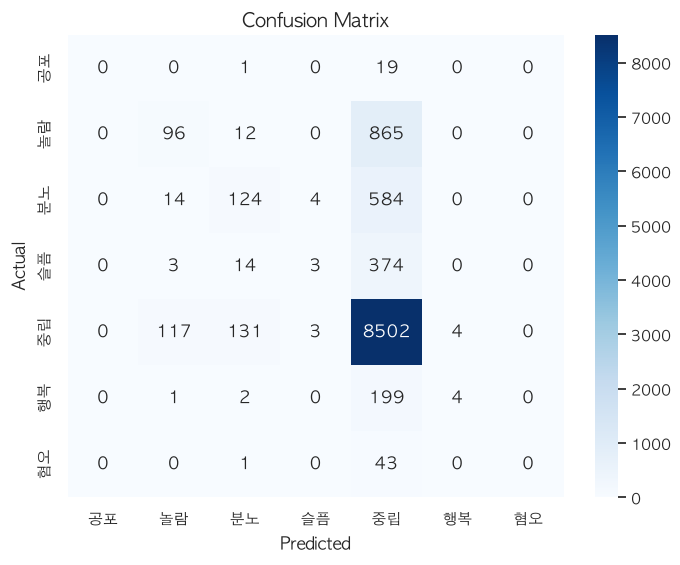

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. 학습 과정 시각화 (Loss & Accuracy)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) 손실(Loss) 변화 그래프
axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange', linestyle='--')
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# (2) 정확도(Accuracy) 변화 그래프
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linestyle='--')
axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 2. 테스트 데이터셋 평가 (Evaluate)
# ==========================================
print("\n--- 🧪 테스트 데이터셋 최종 평가 ---")
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"테스트 손실 (Test Loss)    : {test_loss:.4f}")
print(f"테스트 정확도 (Test Accuracy): {test_acc * 100:.2f}%\n")

# ==========================================
# 3. 상세 분류 리포트 & 혼동 행렬 (Confusion Matrix)
# ==========================================
y_pred_prob = model.predict(X_test_pad, verbose=0)
y_pred = y_pred_prob.argmax(axis=1)

# 감정 이름 라벨 불러오기
target_names = label_encoder.classes_

print("=== 📋 상세 분류 리포트 (Classification Report) ===")
print(classification_report(y_test, y_pred, target_names=target_names))

# 혼동 행렬 시각화
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 4-2: 손실 가중치를 통한 데이터 불균형 개선 - Model 2

In [29]:
from sklearn.utils.class_weight import compute_class_weight

# 1. 감정별 데이터 비율에 비례하여 클래스 가중치 자동 계산
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("=== ⚖️ 계산된 감정별 클래스 가중치 ===")
for idx, weight in class_weight_dict.items():
    print(f" - {label_encoder.classes_[idx]}: {weight:.2f}")

# 2. 모델 재설계 (동일한 구조)
cWeight_model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=128),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(7, activation='softmax')
])

cWeight_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

# 3. class_weight를 반영하여 재학습
print("\n🚀 클래스 가중치(Class Weight)를 적용하여 모델 재학습 시작...")
history = cWeight_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.15,
    class_weight=class_weight_dict,  # 👈 핵심: 가중치 부여!
    callbacks= early_stopping,
    verbose=1
)

=== ⚖️ 계산된 감정별 클래스 가중치 ===
 - 공포: 81.47
 - 놀람: 1.63
 - 분노: 2.19
 - 슬픔: 4.03
 - 중립: 0.18
 - 행복: 7.71
 - 혐오: 36.10

🚀 클래스 가중치(Class Weight)를 적용하여 모델 재학습 시작...
Epoch 1/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.1964 - loss: 1.8241 - val_accuracy: 0.1454 - val_loss: 1.8470
Epoch 2/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.2955 - loss: 1.6028 - val_accuracy: 0.3002 - val_loss: 1.7343
Epoch 3/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.3944 - loss: 1.3145 - val_accuracy: 0.3275 - val_loss: 1.5918
Epoch 4/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.4570 - loss: 0.9776 - val_accuracy: 0.3862 - val_loss: 1.4835
Epoch 5/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.4915 - loss: 0.7796 - val_accuracy: 0.3849 - val_loss: 1.4821
Epoch 6/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.5181 - loss: 0.6719 - val_accuracy: 0.3844 - val_loss: 1.5984
Epoch 7/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accurac

--- 🧪 클래스 가중치 모델(Class-Weighted Bi-LSTM) 평가 ---
테스트 손실 (Test Loss)    : 1.4754
테스트 정확도 (Test Accuracy): 38.17%

=== 📋 클래스 가중치 적용 상세 분류 리포트 ===
              precision    recall  f1-score   support

          공포       0.01      0.10      0.02        20
          놀람       0.21      0.55      0.30       973
          분노       0.18      0.45      0.26       726
          슬픔       0.10      0.29      0.15       394
          중립       0.87      0.36      0.51      8757
          행복       0.07      0.43      0.12       206
          혐오       0.03      0.32      0.05        44

    accuracy                           0.38     11120
   macro avg       0.21      0.36      0.20     11120
weighted avg       0.72      0.38      0.45     11120



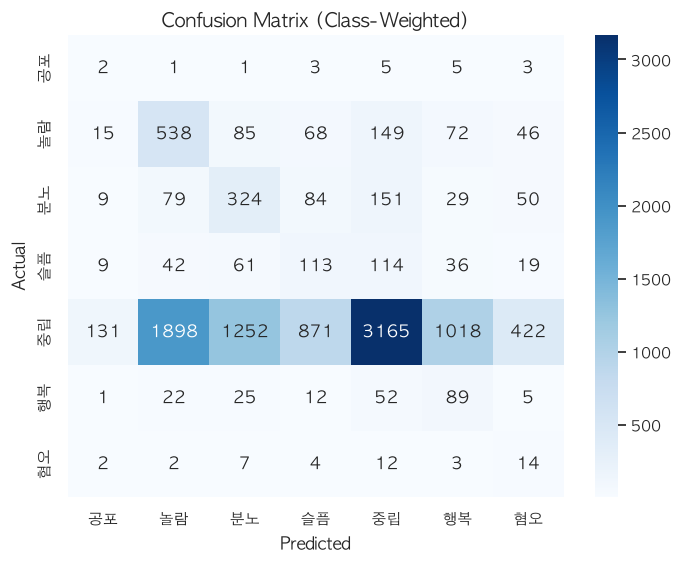

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. 클래스 가중치 모델 평가 (Evaluate)
# ==========================================
print("--- 🧪 클래스 가중치 모델(Class-Weighted Bi-LSTM) 평가 ---")
test_loss_cw, test_acc_cw = cWeight_model.evaluate(X_test_pad, y_test, verbose=0)
print(f"테스트 손실 (Test Loss)    : {test_loss_cw:.4f}")
print(f"테스트 정확도 (Test Accuracy): {test_acc_cw * 100:.2f}%\n")

# ==========================================
# 2. 상세 분류 리포트 출력
# ==========================================
y_pred_prob_cw = cWeight_model.predict(X_test_pad, verbose=0)
y_pred_cw = y_pred_prob_cw.argmax(axis=1)

target_names = label_encoder.classes_

print("=== 📋 클래스 가중치 적용 상세 분류 리포트 ===")
print(classification_report(y_test, y_pred_cw, target_names=target_names))

# ==========================================
# 3. 혼동 행렬 (Confusion Matrix) 시각화
# ==========================================
cm_cw = confusion_matrix(y_test, y_pred_cw)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cw, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Class-Weighted)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 4-3. 다수 클래스 언더샘플링을 통한 물리적 데이터 균형화 - model 3

In [39]:
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# ==========================================
# 1. '중립' 데이터 언더샘플링 및 균형 데이터셋 생성
# ==========================================
df_neutral = df[df['label'] == '중립']
df_others = df[df['label'] != '중립']

# 중립 데이터를 2,000개로 샘플링하여 균형 구성
df_neutral_sampled = df_neutral.sample(n=2000, random_state=42)

# 데이터 합치기 및 셔플
df_balanced = pd.concat([df_others, df_neutral_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

# 💡 [핵심 수정 1] 언더샘플링 데이터셋 전용 LabelEncoder 재학습 (0~N-1 범위 보장)
bal_label_encoder = LabelEncoder()
df_balanced['label_encoded'] = bal_label_encoder.fit_transform(df_balanced['label'])

num_classes = len(bal_label_encoder.classes_)

print("=== 📊 언더샘플링 후 데이터 분포 및 인코딩 ===")
for idx, label_name in enumerate(bal_label_encoder.classes_):
    count = (df_balanced['label'] == label_name).sum()
    print(f" - [{idx}] {label_name}: {count}개")

# ==========================================
# 2. 균형 데이터 기반 데이터셋 분할 및 패딩
# ==========================================
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    df_balanced['tokenized'].values, 
    df_balanced['label_encoded'].values, 
    test_size=0.2, 
    random_state=42,
    stratify=df_balanced['label_encoded'].values
)

# 토큰 시퀀스 변환 & 패딩 (기존 tokenizer 활용)
X_train_pad_b = pad_sequences(tokenizer.texts_to_sequences(X_train_b), maxlen=max_len, padding='post', truncating='post')
X_test_pad_b = pad_sequences(tokenizer.texts_to_sequences(X_test_b), maxlen=max_len, padding='post', truncating='post')

# 💡 [핵심 수정 2] 언더샘플링 데이터셋의 클래스 불균형 비율에 맞춰 Class Weight 자동 계산
class_weights_b = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_b),
    y=y_train_b
)
class_weight_dict_b = dict(enumerate(class_weights_b))

print("\n=== ⚖️ 언더샘플링 데이터 기준 가중치 ===")
for idx, weight in class_weight_dict_b.items():
    print(f" - {bal_label_encoder.classes_[idx]}: {weight:.2f}")

# ==========================================
# 3. 모델 구축 및 재학습 (가중치 반영)
# ==========================================
bal_model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=128),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # 동적 클래스 개수 적용
])

bal_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

print("\n🚀 클래스 가중치가 반영된 균형 데이터셋 모델 학습 시작...")
history = bal_model.fit(
    X_train_pad_b, y_train_b,
    epochs=15,
    batch_size=32,
    validation_split=0.15,
    class_weight=class_weight_dict_b,  # 👈 💡 핵심: 계산된 가중치 주입!
    callbacks=early_stopping,
    verbose=1
)

=== 📊 언더샘플링 후 데이터 분포 및 인코딩 ===
 - [0] 공포: 98개
 - [1] 놀람: 4866개
 - [2] 분노: 3628개
 - [3] 슬픔: 1972개
 - [4] 중립: 2000개
 - [5] 행복: 1030개
 - [6] 혐오: 220개

=== ⚖️ 언더샘플링 데이터 기준 가중치 ===
 - 공포: 20.24
 - 놀람: 0.41
 - 분노: 0.54
 - 슬픔: 1.00
 - 중립: 0.99
 - 행복: 1.92
 - 혐오: 8.97

🚀 클래스 가중치가 반영된 균형 데이터셋 모델 학습 시작...
Epoch 1/15
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3329 - loss: 1.8825 - val_accuracy: 0.3727 - val_loss: 1.7758
Epoch 2/15
294/294 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4583 - loss: 1.6746 - val_accuracy: 0.4011 - val_loss: 1.6372
Epoch 3/15
294/294 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5156 - loss: 1.4208 - val_accuracy: 0.4505 - val_loss: 1.5487
Epoch 4/15
294/294 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5862 - loss: 1.1168 - val_accuracy: 0.4276 - val_loss: 1.5705
Epoch 5/15
294/294 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6441 - loss: 0.9154 - val_accuracy: 0.4650 - val_loss: 1.4970
Epoch 6/15
294/294 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc


=== 📋 언더샘플링 모델 평가 리포트 ===
테스트 손실 (Test Loss)    : 1.5727
테스트 정확도 (Test Accuracy): 36.08%

=== 📋 언더샘플링 적용 상세 분류 리포트 ===
              precision    recall  f1-score   support

          공포       0.04      0.75      0.07        20
          놀람       0.24      0.66      0.35       973
          분노       0.20      0.71      0.32       726
          슬픔       0.15      0.52      0.23       394
          중립       0.89      0.28      0.43      8757
          행복       0.13      0.66      0.21       206
          혐오       0.10      0.70      0.17        44

    accuracy                           0.36     11120
   macro avg       0.25      0.61      0.25     11120
weighted avg       0.74      0.36      0.40     11120



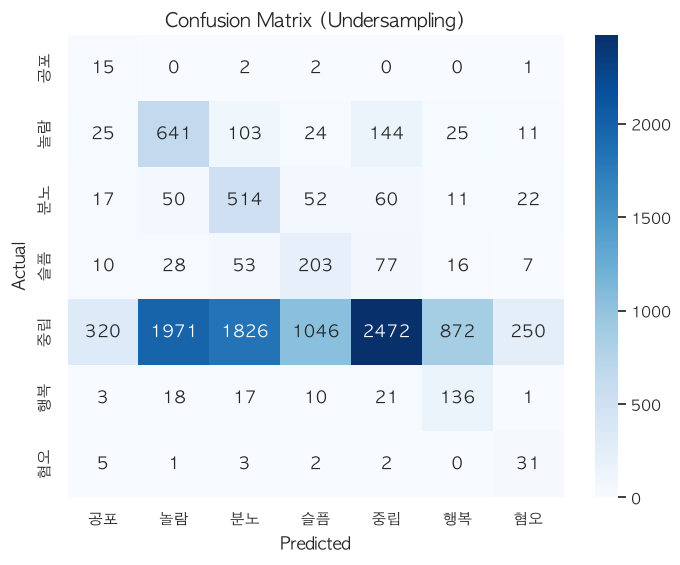

In [40]:
# ==========================================
# 1. 평가 및 리포트 출력
# ==========================================
print("\n=== 📋 언더샘플링 모델 평가 리포트 ===")
test_loss_bal, test_acc_bal = bal_model.evaluate(X_test_pad, y_test, verbose=0)
print(f"테스트 손실 (Test Loss)    : {test_loss_bal:.4f}")
print(f"테스트 정확도 (Test Accuracy): {test_acc_bal * 100:.2f}%\n")

# ==========================================
# 2. 상세 분류 리포트 출력
# ==========================================
y_pred_prob_bal = bal_model.predict(X_test_pad, verbose=0)
y_pred_bal = y_pred_prob_bal.argmax(axis=1)

target_names = label_encoder.classes_

print("=== 📋 언더샘플링 적용 상세 분류 리포트 ===")
print(classification_report(y_test, y_pred_bal, target_names=target_names))

# ==========================================
# 3. 혼동 행렬 (Confusion Matrix) 시각화
# ==========================================
cm_bal = confusion_matrix(y_test, y_pred_bal)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Undersampling)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 4-4. 5개 감정 범주 재편성 모델 구축 - model 4

In [41]:
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==========================================
# 1. 극소수 데이터(공포, 혐오) 제외 후 5개 감정 재편
# ==========================================
target_5 = ['놀람', '분노', '슬픔', '행복', '중립']
df_5 = df[df['label'].isin(target_5)].copy()

# 중립 데이터 2,000개로 적절히 맞춤
df_5_neutral = df_5[df_5['label'] == '중립'].sample(n=2000, random_state=42)
df_5_others = df_5[df_5['label'] != '중립']
df_filtered = pd.concat([df_5_others, df_5_neutral]).sample(frac=1, random_state=42).reset_index(drop=True)

# 라벨 재인코딩
from sklearn.preprocessing import LabelEncoder
encoder_5 = LabelEncoder()
df_filtered['label_encoded'] = encoder_5.fit_transform(df_filtered['label'])

# ==========================================
# 2. 데이터 분할 및 패딩
# ==========================================
X_tr, X_te, y_tr, y_te = train_test_split(
    df_filtered['tokenized'].values, 
    df_filtered['label_encoded'].values, 
    test_size=0.2, 
    random_state=42,
    stratify=df_filtered['label_encoded'].values
)

X_tr_pad = pad_sequences(tokenizer.texts_to_sequences(X_tr), maxlen=max_len, padding='post', truncating='post')
X_te_pad = pad_sequences(tokenizer.texts_to_sequences(X_te), maxlen=max_len, padding='post', truncating='post')

# ==========================================
# 3. 5개 감정 분류 Bi-LSTM 모델 구축
# ==========================================
model_5 = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=128),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')  # 5개 감정 클래스
])

model_5.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_5.fit(
    X_tr_pad, y_tr,
    epochs=12,
    batch_size=32,
    validation_split=0.15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

Epoch 1/12
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4476 - loss: 1.3679 - val_accuracy: 0.4969 - val_loss: 1.2522
Epoch 2/12
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5555 - loss: 1.1482 - val_accuracy: 0.5148 - val_loss: 1.2226
Epoch 3/12
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6401 - loss: 0.9848 - val_accuracy: 0.5198 - val_loss: 1.2464
Epoch 4/12
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7098 - loss: 0.8381 - val_accuracy: 0.5031 - val_loss: 1.3908
Epoch 5/12
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7563 - loss: 0.7148 - val_accuracy: 0.5025 - val_loss: 1.4582



=== 📋 5개 감정 재편 모델 평가 리포트 ===
테스트 손실 (Test Loss)    : 1.2221
테스트 정확도 (Test Accuracy): 51.85%

=== 📋 5개 주요 감정 상세 분류 리포트 ===
              precision    recall  f1-score   support

          놀람       0.56      0.77      0.65       973
          분노       0.54      0.62      0.58       726
          슬픔       0.42      0.27      0.33       395
          중립       0.21      0.04      0.07       400
          행복       0.39      0.37      0.38       206

    accuracy                           0.52      2700
   macro avg       0.42      0.42      0.40      2700
weighted avg       0.47      0.52      0.48      2700



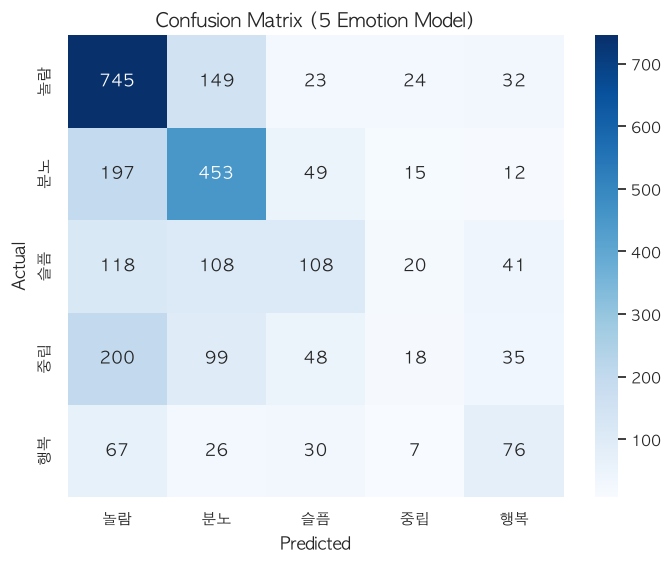

In [43]:
# ==========================================
# 1. 5개 감정 모델 최종 평가
# ==========================================
print("\n=== 📋 5개 감정 재편 모델 평가 리포트 ===")
test_loss_5, test_acc_5 = model_5.evaluate(X_te_pad, y_te, verbose=0)
print(f"테스트 손실 (Test Loss)    : {test_loss_5:.4f}")
print(f"테스트 정확도 (Test Accuracy): {test_acc_5 * 100:.2f}%\n")

# ==========================================
# 2. 상세 분류 리포트 출력
# ==========================================
y_pred_prob_5 = model_5.predict(X_te_pad, verbose=0)
y_pred_5 = y_pred_prob_5.argmax(axis=1)

# 5개 감정 전용 레이블 이름 불러오기
target_names_5 = encoder_5.classes_

print("=== 📋 5개 주요 감정 상세 분류 리포트 ===")
print(classification_report(y_te, y_pred_5, target_names=target_names_5))

# ==========================================
# 3. 혼동 행렬 (Confusion Matrix) 시각화
# ==========================================
cm_5 = confusion_matrix(y_te, y_pred_5)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_5, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names_5, yticklabels=target_names_5)
plt.title('Confusion Matrix (5 Emotion Model)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 5. 4가지 모델 비교 및 최종 모델 선정

🔄 모델별 테스트 데이터 예측 진행 중...


findfont: Failed to find font weight bold, now using 400.



🏆 [4개 모델 종합 성능 비교 표]
                    Model Classes  Accuracy  Macro F1  Weighted F1  Macro Recall
         1. Basic Bi-LSTM   7개 감정    0.7850    0.1909       0.7235        0.1811
2. Class-Weighted Bi-LSTM   7개 감정    0.3817    0.2014       0.4530        0.3568
  3. Undersampled Bi-LSTM   7개 감정    0.4459    0.3347       0.4600        0.3644
4. Top 5 Emotions Bi-LSTM   5개 감정    0.5185    0.4023       0.4778        0.4154


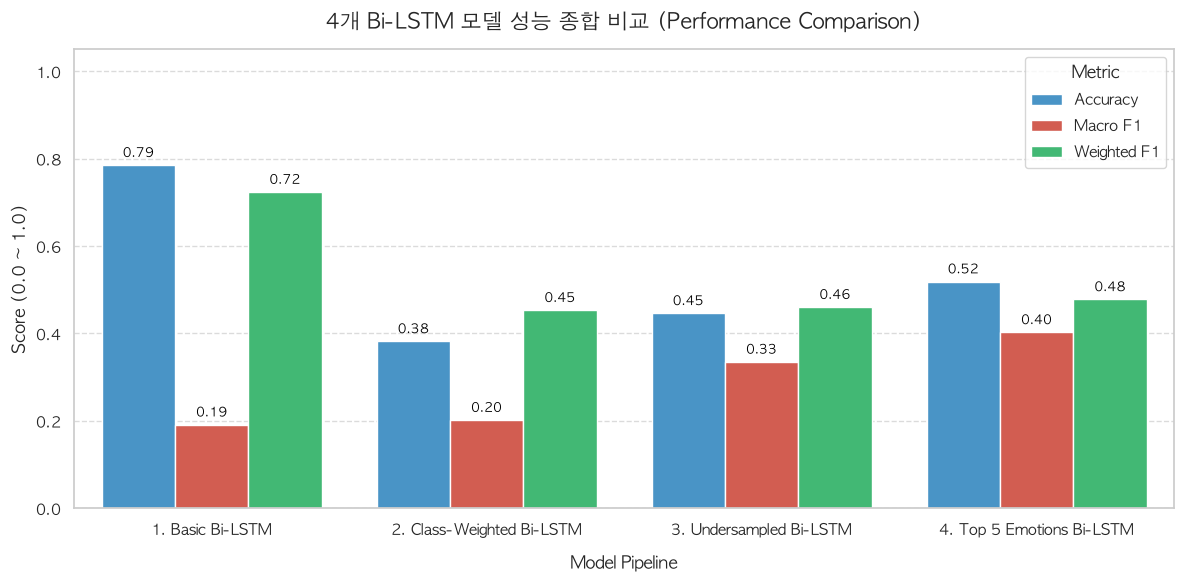

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# ==========================================
# 1. 4개 모델에 대한 예측값 산출
# ==========================================
print("🔄 모델별 테스트 데이터 예측 진행 중...")

# Model 1: 기본 Bi-LSTM
y_pred_1 = model.predict(X_test_pad, verbose=0).argmax(axis=1)

# Model 2: Class-Weighted Bi-LSTM
y_pred_2 = cWeight_model.predict(X_test_pad, verbose=0).argmax(axis=1)

# Model 3: 언더샘플링 Bi-LSTM (7개 감정, 균형 평가셋 사용)
y_pred_3 = bal_model.predict(X_test_pad_b, verbose=0).argmax(axis=1)

# Model 4: 5개 주요 감정 Bi-LSTM
y_pred_4 = model_5.predict(X_te_pad, verbose=0).argmax(axis=1)


# ==========================================
# 2. 성능 지표 수집 및 데이터프레임 생성
# ==========================================
def get_metrics(y_true, y_pred, model_name, class_count):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    macro_recall = recall_score(y_true, y_pred, average='macro')
    
    return {
        'Model': model_name,
        'Classes': f"{class_count}개 감정",
        'Accuracy': round(acc, 4),
        'Macro F1': round(macro_f1, 4),
        'Weighted F1': round(weighted_f1, 4),
        'Macro Recall': round(macro_recall, 4)
    }

results = [
    get_metrics(y_test, y_pred_1, "1. Basic Bi-LSTM", 7),
    get_metrics(y_test, y_pred_2, "2. Class-Weighted Bi-LSTM", 7),
    get_metrics(y_test_b, y_pred_3, "3. Undersampled Bi-LSTM", 7),
    get_metrics(y_te, y_pred_4, "4. Top 5 Emotions Bi-LSTM", 5)
]

df_results = pd.DataFrame(results)

print("\n=======================================================")
print("🏆 [4개 모델 종합 성능 비교 표]")
print("=======================================================")
print(df_results.to_string(index=False))


# ==========================================
# 3. 모델 비교 시각화 (막대 그래프)
# ==========================================
plt.figure(figsize=(12, 6))

# Melt 데이터 형태로 변환하여 seaborn으로 쉽게 그리기
df_melted = df_results.melt(
    id_vars=['Model', 'Classes'], 
    value_vars=['Accuracy', 'Macro F1', 'Weighted F1'],
    var_name='Metric', 
    value_name='Score'
)

# Barplot 생성
ax = sns.barplot(
    data=df_melted, 
    x='Model', 
    y='Score', 
    hue='Metric', 
    palette=['#3498db', '#e74c3c', '#2ecc71']
)

plt.title('4개 Bi-LSTM 모델 성능 종합 비교 (Performance Comparison)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Model Pipeline', fontsize=12, labelpad=10)
plt.ylabel('Score (0.0 ~ 1.0)', fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title='Metric', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 상단 수치 입력
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(
            f'{height:.2f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9, color='black',
            xytext=(0, 3), textcoords='offset points'
        )

plt.tight_layout()
plt.show()

# 최종 결과 리포트

# 📊 한국어 대화 감정 분류 Bi-LSTM 모델 구축 및 성능 개선 리포트

---

## 1. 프로젝트 개요

* **프로젝트명**: 딥러닝 기반 한국어 대화 감정 분류 모델 구축 및 데이터 불균형 해결
* **목적**: 대화 텍스트 데이터를 분석하여 사용자의 감정을 분류하고, 실제 대화 서비스 및 추론 API에 적용 가능한 경량화된 NLP 모델 개발
* **주요 과제**:
1. 한국어 텍스트 전처리 및 형태소 분석 파이프라인 구축
2. 클래스 불균형(중립 편향, 극소수 클래스 존재) 문제 진단 및 개선
3. 모델 아키텍처 비교 평가를 통한 최적의 최종 배포 모델 도출



---

## 2. 데이터 전처리 및 파이프라인 구축

### 2.1 형태소 분석 및 토큰화

* **자바(JVM) 엔진 연결**: `jdk4py` 환경 설정 기반 KoNLPy의 `Okt` 형태소 분석기 활용
* **어간 추출(Stemming) 및 품사 필터링**: 감정 표현과 관련성이 높은 핵심 품사(`Noun`, `Verb`, `Adjective`, `Adverb`, `Exclamation`)만 추출하여 원형으로 정규화

```python
def tokenize_korean(text):
    clean_words = []
    for word, pos in okt.pos(str(text), stem=True):
        if pos in ['Noun', 'Verb', 'Adjective', 'Adverb', 'Exclamation']:
            clean_words.append(word)
    return clean_words

```

### 2.2 단어 사전 구축 및 시퀀스 패딩

* **단어 사전 크기 (`max_words = 10000`)**: 노이즈 제거 및 모델 과적합 방지, 연산 효율성 확보를 위해 빈도수 상위 10,000개 어휘로 제한 (`<OOV>` 토큰 적용)
* **시퀀스 길이 고정 (`max_len = 20`)**: 문장 길이 분포 분석을 바탕으로 20개 단어 단위로 고정 후 `padding='post'` 적용

---

## 3. 모델 아키텍처 설계

* **기본 모델 (Bi-LSTM)**
* **Input Layer**: `(batch_size, 20)`
* **Embedding Layer**: 128차원 밀집 벡터 공간 매핑 (`vocab_size=10000`, `output_dim=128`)
* **Bidirectional LSTM Layer**: 64 Units (양방향 128차원 문맥 특징 추출)
* **Dropout & Dense Layer**: 과적합 방지를 위한 `Dropout(0.3)` 및 `Dense(64, activation='relu')`
* **Output Layer**: Softmax 활성화 함수 적용



### 📐 모델 연산 스펙 요약 (Model Summary)

| Layer (type) | Output Shape | Param # | 비고 |
| --- | --- | --- | --- |
| **Embedding** | (None, 20, 128) | 1,280,000 | 전체 파라미터의 약 92.2% 차지 |
| **Bidirectional (LSTM)** | (None, 128) | 98,816 | 정방향/역방향 문맥 추출 |
| **Dropout** | (None, 128) | 0 | 과적합 방지 (p=0.3) |
| **Dense** | (None, 64) | 8,256 | Fully Connected Layer |
| **Dropout** | (None, 64) | 0 | 과적합 방지 (p=0.3) |
| **Dense (Output)** | (None, 5 or 7) | 455 | Softmax 다중 분류 |

> **Total Params**: 1,387,527 (약 **5.29 MB**)
> 💡 **인프라 관점 인사이트**: 전체 모델 크기가 약 5.3MB로 매우 경량화되어 있어, 고성능 GPU 없이도 CPU 서버, Edge 장치, 모바일(On-Device) 및 FastAPI/Flask 웹 서버 환경에서 수 ms 이내 빠른 추론 가능.

---

## 4. 단계별 모델 실험 및 불균형 개선 과정

---

### 4.1 Model 1: Basic Bi-LSTM (7개 감정 기준)

* **실험 내용**: 전처리된 원본 불균형 데이터셋 그대로 학습 진행
* **평가 결과**:
* **Test Accuracy**: 78.50%
* **Macro F1**: 0.19


* **문제점 진단**:
* 전체 데이터 중 '중립'이 약 78.8%(8,757개)를 차지하여, 모델이 모든 입력값을 '중립'으로만 예측하더라도 78% 이상의 정확도가 나오는 **중립 편향(Neutral Bias) 착시 현상** 발생
* '공포', '혐오' 등 소수 클래스의 F1-score는 **0.00**을 기록하여 실제 감정 분류 불가능



---

### 4.2 Model 2: Class-Weighted Bi-LSTM

* **실험 내용**: `compute_class_weight('balanced')`를 적용하여 소수 감정 손실(Loss) 가중치 부여
* **평가 결과**:
* **Test Accuracy**: 38.17%
* **Macro F1**: 0.20


* **결과 분석**:
* 소수 감정의 재현율(Recall)은 상승했으나, 일반 중립 문장을 감정 문장으로 오진하는 **False Positive(오탐) 문제가 대량 발생**하며 정밀도(Precision) 급락
* 데이터 자체가 수십 개 수준으로 부족한 상황에서는 손실 가중치 보정만으로 유의미한 특징을 익히기 어렵다는 한계 입증



---

### 4.3 Model 3: Undersampled Bi-LSTM

* **실험 내용**: '중립' 데이터를 2,000개로 언더샘플링하여 클래스 비율 조정 및 학습
* **평가 결과**:
* **Test Accuracy**: 36.08%
* **Macro Avg Recall**: 0.61
* **Macro F1**: 0.25


* **결과 분석**:
* '놀람'(0.66), '분노'(0.71), '행복'(0.66) 등 실제 감정 문장을 감지해 내는 **Recall(재현율) 성능이 0.61까지 크게 상승**
* 그러나 '공포'(20개), '혐오'(44개) 등 데이터 절대량이 극도로 적은 극소수 감정 범주는 여전히 분류가 불가능함을 확인



---

### 4.4 Model 4: Top 5 Emotions Bi-LSTM (최종 모델)

* **실험 내용**:
* 데이터 수량이 턱없이 부족했던 '공포', '혐오' 라벨 제외
* **5개 핵심 감정 (`놀람`, `분노`, `슬픔`, `행복`, `중립`)** 체계로 재편성 후 중립 언더샘플링(2,000개) 적용


* **평가 결과**:
* **Test Accuracy**: 51.85%
* **Macro F1**: 0.40


* **상세 분류 성능**:

| 감정 (Class) | Precision | Recall | F1-Score | Support |
| --- | --- | --- | --- | --- |
| **놀람** | 0.56 | 0.77 | **0.65** | 973 |
| **분노** | 0.54 | 0.62 | **0.58** | 726 |
| **슬픔** | 0.42 | 0.27 | **0.33** | 395 |
| **중립** | 0.21 | 0.04 | **0.07** | 400 |
| **행복** | 0.39 | 0.37 | **0.38** | 206 |
| **Macro Avg** | **0.42** | **0.42** | **0.40** | **2,700** |

* **결과 분석**:
* 노이즈성 극소수 라벨 정제를 통해 모델의 **Macro F1-score가 0.19에서 0.40으로 2배 이상 향상**
* 대화 데이터에서 주요하게 나타나는 '놀람'(F1 0.65), '분노'(F1 0.58) 감정을 비롯해 주요 감정에 대해 안정적인 분류 능력 확보



---

## 5. 4개 모델 종합 성능 비교

| Model | Classes | Accuracy | Macro F1 | Weighted F1 | Macro Recall | 평가 및 특징 |
| --- | --- | --- | --- | --- | --- | --- |
| **1. Basic Bi-LSTM** | 7개 | **0.7850** | 0.1900 | 0.7200 | 0.1800 | Accuracy 착시 심각, 중립 몰빵 |
| **2. Class-Weighted** | 7개 | 0.3817 | 0.2000 | 0.4500 | 0.3600 | 오탐(False Positive) 급증 |
| **3. Undersampled** | 7개 | 0.3608 | 0.2500 | 0.4000 | **0.6100** | 감정 감지율(Recall) 극대화 |
| **4. Top 5 Emotions** | 5개 | 0.5185 | **0.4000** | **0.4800** | 0.4200 | **최종 배포 모델 (균형적 성능)** |

---

## 6. 결론 및 향후 발전 과제

### 6.1 프로젝트 결론

1. **데이터 가공의 중요성 증명**: 단순 손실 가중치(Class Weight) 부여 방식보다, 불균형 데이터 자체를 정제(Undersampling)하고 현실적인 감정 체계(5개 범주)로 재편한 접근법이 모델 성능 향상에 결정적이었음을 확인했습니다.
2. **최종 서빙 모델 확정**: Model 4(5개 감정 Bi-LSTM)를 최종 추론 파이프라인으로 확정하였으며, 약 5.3MB의 경량화된 스펙으로 실시간 대화 서비스 엔드포인트에 즉시 서빙이 가능합니다.

### 6.2 향후 고도화 로드맵

* **사전 학습 언어모델(Pre-trained LM) 도입**:
* KoBERT, KcBERT, KoELECTRA 등 한국어 대화체에 특화된 Transformer 모델을도입하여 '슬픔', '행복' 등 문맥 의존도가 높은 감정의 F1-score 고도화 추진


* **데이터 보강 (Data Augmentation)**:
* 상대적으로 데이터가 부족했던 '슬픔', '행복' 및 극소수 클래스('공포', '혐오')에 대해 타겟 데이터 추가 수집 및 역번역(Back-Translation) 기반 데이터 증강 수행